In [ ]:
%pip install -q rasterio geopandas torch torchvision numpy scikit-image matplotlib tqdm albumentations tensorboard


In [ ]:
import os
import glob
import numpy as np
import rasterio
from rasterio.mask import mask
import geopandas as gpd
import torch
from torch.utils.data import Dataset, DataLoader
import string


# CRS Management

In [ ]:
import rasterio
from rasterio.transform import from_origin
import piexif
from PIL import Image

def add_crs_to_tiff(input_tif, output_tif, crs_epsg=25829):
    """
    Adds CRS (e.g., ETRS89 / UTM zone 29N) to a TIFF using GPS EXIF metadata.
    
    Args:
        input_tif (str): Path to input TIFF image.
        output_tif (str): Path to output TIFF with CRS set.
        crs_epsg (int): EPSG code for the CRS to assign (default=25829).
    """

    # Step 1: Read EXIF GPS metadata
    img = Image.open(input_tif)
    exif_dict = piexif.load(input_tif)
    gps = exif_dict.get("GPS", {})

    if not gps:
        raise ValueError("No GPS EXIF data found in the image.")

    def convert_to_degrees(value):
        """Convert GPS rational coordinates to decimal degrees."""
        d = value[0][0] / value[0][1]
        m = value[1][0] / value[1][1]
        s = value[2][0] / value[2][1]
        return d + (m / 60.0) + (s / 3600.0)

    lat = convert_to_degrees(gps[piexif.GPSIFD.GPSLatitude])
    if gps.get(piexif.GPSIFD.GPSLatitudeRef) == b'S':
        lat = -lat

    lon = convert_to_degrees(gps[piexif.GPSIFD.GPSLongitude])
    if gps.get(piexif.GPSIFD.GPSLongitudeRef) == b'W':
        lon = -lon

    # Step 2: Open TIFF data as array and capture profile while file is open
    with rasterio.open(input_tif) as src:
        data = src.read()
        transform = from_origin(lon, lat, src.res[0], src.res[1])
        # copy profile while src is still open to avoid "Dataset is closed" errors
        profile = src.profile.copy()

    # Step 3: Write new TIFF with CRS
    profile.update({
        "driver": "GTiff",
        "crs": f"EPSG:{crs_epsg}",
        "transform": transform
    })

    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(data)

    print(f"✅ CRS (EPSG:{crs_epsg}) assigned and saved to {output_tif}")

# Example usage
input_dir = "/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/30_V1/30_V1/SET"
output_dir = "/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/dataset/Vineyard_Disease_Pontevedra/curated/"

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    input_path = os.path.join(input_dir, filename)
    # Process only files (not directories)
    if os.path.isfile(input_path) and filename.lower().endswith(".tif"):
        output_path = os.path.join(output_dir, "30_V1-"+filename)
        add_crs_to_tiff(input_path,output_path)
    else:
        print(f"Skipping {input_path}, not a file.")


# Dataset

In [ ]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.transform import Affine
# from rasterio.control import GroundControlPoint
import os


def compute_affine_from_gcps(gcp_shp_path, img_width, img_height):
    """
    Compute an affine transform between approximate pixel coordinates
    (col, row) and real-world coordinates (X, Y) using least squares.
    """
    gdf = gpd.read_file(gcp_shp_path)
    if gdf.crs is None:
        gdf.set_crs("EPSG:25829", inplace=True)

    # Sort by ID to make mapping reproducible
    gdf = gdf.sort_values(by="id").reset_index(drop=True)

    n = len(gdf)
    if n < 3:
        raise ValueError("Need at least 3 GCPs to estimate affine transform.")

    # --- Step 1. Assign approximate pixel grid positions ---
    # Assume GCPs roughly distributed across image area
    cols = np.linspace(0, img_width, n)
    rows = np.linspace(0, img_height, n)
    cols = np.clip(cols, 0, img_width - 1)
    rows = np.clip(rows, 0, img_height - 1)

    # --- Step 2. Fit least squares affine transform ---
    A = []
    bx = []
    by = []
    for i in range(n):
        A.append([cols[i], rows[i], 1, 0, 0, 0])
        A.append([0, 0, 0, cols[i], rows[i], 1])
        bx.append(gdf.geometry[i].x)
        by.append(gdf.geometry[i].y)

    A = np.array(A)
    b = np.array(bx + by)
    params, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c, d, e, f = params
    affine = Affine(a, b_, c, d, e, f)

    print(affine)
    return affine, gdf.crs


def load_multispectral_image(path_prefix, gcp_shp_path=None):
    """
    Load and stack bands from a single large multiband TIFF (preferred) or a directory
    of per-band TIFFs. Do NOT perform any CRS alignment here — files already contain everything.
    Returns stacked (B, H, W) float32 and meta dict (rasterio meta).
    """
    bands_data = []
    meta = None

    # If path_prefix is a file, open it and read the requested bands
    if os.path.exists(path_prefix) and os.path.isfile(path_prefix):
        with rasterio.open(path_prefix) as src:
            meta = src.meta.copy()
            # read all bands available (or limit to BANDS present in file)
            available = src.count
            read_bands = [b for b in BANDS if 1 <= b <= available]
            if not read_bands:
                raise RuntimeError(f"No requested bands {BANDS} available in {path_prefix} (count={available})")
            for b in read_bands:
                bands_data.append(src.read(b).astype(np.float32))
    else:
        # fallback: treat path_prefix as directory/prefix and try per-band files
        # try prefix + "_<b>.tif"
        paths = [f"{path_prefix}_{b}.tif" for b in BANDS]
        found = False
        for p in paths:
            print(p)
            if os.path.exists(p):
                found = True
                with rasterio.open(p) as src:
                    if meta is None:
                        meta = src.meta.copy()
                    bands_data.append(src.read(1).astype(np.float32))
        if not found:
            # try find any .tif inside directory
            tif_list = sorted(glob.glob(os.path.join(path_prefix, "*.tif")))
            if tif_list:
                # if a single multiband tif found inside directory, use first
                with rasterio.open(tif_list[0]) as src:
                    meta = src.meta.copy()
                    for b in range(1, min(src.count, max(BANDS)) + 1):
                        bands_data.append(src.read(b).astype(np.float32))
            else:
                raise FileNotFoundError(f"No TIFF file found at '{path_prefix}' nor matching band files.")

    stacked = np.stack(bands_data, axis=0).astype(np.float32)  # (B, H, W)

    # Do not modify CRS/transform here. If GCPs requested, caller may compute externally.
    return stacked, meta

# Vegetation indices
def compute_ndvi(stacked):
    """Compute NDVI from multispectral bands (assumes RedEdge sensor order)."""
    nir = stacked[3]
    red = stacked[2]
    ndvi = (nir - red) / (nir + red + 1e-6)
    return np.clip(ndvi, -1, 1)

def compute_ndre(stacked):
    red_edge = stacked[4]
    nir = stacked[3]
    ndre = (nir - red_edge) / (nir + red_edge + 1e-6)
    return np.clip(ndre, -1, 1)


# Align shapefiles
def load_and_align_shapefile(path, reference_meta):
    """Reproject shapefile to the raster CRS."""
    gdf = gpd.read_file(path)
    if gdf.crs != reference_meta['crs']:
        gdf = gdf.to_crs(reference_meta['crs'])
    return gdf

def rasterize_shapes(shapefile, reference_raster):
    """Rasterizes shapefile polygons to match raster grid."""
    import rasterio.features
    with rasterio.open(reference_raster) as src:
        meta = src.meta.copy()
        transform = src.transform
        out_shape = (src.height, src.width)

    gdf = gpd.read_file(shapefile).to_crs(meta['crs'])
    mask = rasterio.features.rasterize(
        [(geom, 1) for geom in gdf.geometry],
        out_shape=out_shape,
        transform=transform,
        fill=0,
        all_touched=True,
        dtype=np.float32
    )
    return mask

# Patch extraction
def extract_patches(image, patch_size=PATCH_SIZE):
    patches = []
    h, w = image.shape[1], image.shape[2]
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            patch = image[:, y:y+patch_size, x:x+patch_size]
            if patch.shape[1] == patch_size and patch.shape[2] == patch_size:
                patches.append(patch)
    return np.stack(patches)


# Dataset Class - Vineyard Dataset

In [ ]:
#@title Dataset Class - (lazy memory-mapped, huge TIF and multi-TIF support)
from rasterio.windows import Window
from rasterio.enums import Resampling
import rasterio
import glob, os
import numpy as np
import torch
import geopandas as gpd
from torch.utils.data import Dataset

class VineyardDataset(Dataset):
    def __init__(self, data_dir, shapefiles=None, patch_size=128, stride=128, bands=[1,2,3,4,5], gcp_shp_path=None):
        """
        Supports:
          - data_dir: path to a single large multiband TIFF file
          - or a directory containing multiple large TIFF files (each a scene)
          - or per-band TIFFs (prefix_band.tif pattern)

        This implementation lazily reads patches via rasterio windows — no full loading.
        It builds an index of (file, x, y) patch coordinates across all TIFFs.
        """
        print("Initializing VineyardDataset...")
        print(f"Data dir: {data_dir}")
        print(f"Patch size: {patch_size}, Stride: {stride}")
        print(f"gcp_shp_path: {gcp_shp_path}")
        
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.stride = stride
        self.bands = bands
        self.gcp_shp_path = gcp_shp_path

        self.tif_files = []
        self.prefixes = []

        # Detect whether it's a single file or directory of tifs
        if os.path.isfile(data_dir) and data_dir.lower().endswith(".tif"):
            self.tif_files = [os.path.abspath(data_dir)]
            self.prefixes = [os.path.splitext(os.path.basename(data_dir))[0]]
        else:
            self.tif_files = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
            if not self.tif_files:
                raise ValueError(f"No TIFF files found in directory: {data_dir}")
            self.prefixes = [os.path.splitext(os.path.basename(fp))[0] for fp in self.tif_files]

        # Load lightweight metadata for each tif (no raster data)
        self.meta_per_file = {}
        for tif_path in self.tif_files:
            with rasterio.open(tif_path) as src:
                meta = src.meta.copy()
                h, w = src.height, src.width
                meta.update(height=h, width=w)
                self.meta_per_file[tif_path] = meta

        # Build index across all TIFFs
        self.index = []
        for tif_path, prefix in zip(self.tif_files, self.prefixes):
            meta = self.meta_per_file[tif_path]
            h, w = meta["height"], meta["width"]
            for y in range(0, h - patch_size + 1, stride):
                for x in range(0, w - patch_size + 1, stride):
                    self.index.append((tif_path, prefix, x, y))

        # Load shapefiles lazily (assumed aligned with rasters)
        self._loaded_shapefiles = {}
        for key, shp_path in (shapefiles or {}).items():
            if shp_path and os.path.exists(shp_path):
                try:
                    self._loaded_shapefiles[key] = gpd.read_file(shp_path)
                except Exception:
                    self._loaded_shapefiles[key] = None
            else:
                self._loaded_shapefiles[key] = None

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        tif_path, prefix, x, y = self.index[idx]
        imgs_all_bands = []

        # Read patch from large or multi-tif raster lazily
        try:
            with rasterio.open(tif_path) as src:
                window = Window(x, y, self.patch_size, self.patch_size)
                available = src.count
                for b in self.bands:
                    if b < 1 or b > available:
                        raise RuntimeError(f"Band {b} not available in {prefix} ({available} total)")
                    img = src.read(b, window=window, resampling=Resampling.nearest).astype(np.float32)
                    mn, mx = img.min(), img.max()
                    img = (img - mn) / (mx - mn + 1e-8) if (mx - mn) > 1e-8 else np.zeros_like(img)
                    imgs_all_bands.append(img)
        except Exception as e:
            raise RuntimeError(f"Error reading window ({x},{y}) from {tif_path}: {e}")

        if len(imgs_all_bands) != len(self.bands):
            raise RuntimeError(f"Incomplete band read for {prefix} at ({x},{y})")

        img_input = np.stack(imgs_all_bands[:3], axis=0)  # RGB input

        # NDVI computation
        if len(imgs_all_bands) > 2:
            red_patch = imgs_all_bands[2]
            nir_patch = imgs_all_bands[3]
            denom = nir_patch + red_patch + 1e-8
            ndvi_patch = np.clip((nir_patch - red_patch) / denom, -1.0, 1.0)
        else:
            ndvi_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)

        target = np.expand_dims(ndvi_patch, axis=0)

        # Placeholder for masks (lazy rasterization per tif)
        masks = {}
        for key, gdf in self._loaded_shapefiles.items():
            if gdf is not None:
                try:
                    from rasterio.features import rasterize
                    with rasterio.open(tif_path) as ref:
                        mask = rasterize(
                            [(geom, 1) for geom in gdf.geometry],
                            out_shape=(ref.height, ref.width),
                            transform=ref.transform,
                            fill=0,
                            dtype=np.float32
                        )
                        masks[key] = mask[y:y+self.patch_size, x:x+self.patch_size]
                except Exception:
                    masks[key] = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
            else:
                masks[key] = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)

        botrytis_mask = masks.get('botrytis', np.zeros((self.patch_size, self.patch_size), dtype=np.float32))
        trunk_mask = masks.get('trunks', np.zeros((self.patch_size, self.patch_size), dtype=np.float32))
        combined_mask = np.maximum(botrytis_mask, trunk_mask * 2)[np.newaxis, :, :]

        return {
            'image': torch.from_numpy(img_input).float(),
            'target': torch.from_numpy(target).float(),
            'mask': torch.from_numpy(combined_mask).long(),
            'prefix': prefix,
            'coord': (x, y)
        }


In [43]:
# New Dataset instatiation
import os, glob
import numpy as np
import torch
import rasterio
from rasterio.windows import Window
from rasterio.features import rasterize
import geopandas as gpd
from torch.utils.data import Dataset, get_worker_info
import random
import albumentations as A

os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "TRUE"
# os.environ["GDAL_NUM_THREADS"] = "1"
os.environ["CPL_DEBUG"] = "OFF"

class VineyardDataset(Dataset):
    """
    Multi-worker-safe dataset for RGB -> NDVI tasks with optional extra masks.

    Key arguments:
      data_dir: directory or single tif path
      patch_size, stride
      random_crop (bool)
      augment (bool)           -> Albumentations (HWC numpy)
      normalize (bool)         -> per-channel min-max normalization per patch
      extra_mask_shapefiles: dict{name: shapefile_path}
      mask_rasterization: "on_demand" (default) | "preload" | None
         - on_demand: rasterize only the current patch using dataset.window_transform(window).
         - preload: rasterize whole-image masks at init (memory-heavy).
         - None: no masks
    """
    def __init__(
        self,
        data_dir,
        patch_size=128,
        stride=128,
        random_crop=False,
        augment=False,
        normalize=False,
        extra_mask_shapefiles: dict =None,
        mask_rasterization: str ="on_demand",
        include_position_channels=True,
        use_extra_masks=True,
    ):
        super().__init__()
        self.data_dir = data_dir
        self.patch_size = patch_size
        self.stride = stride

        self.random_crop = random_crop
        self.augment_flag = augment
        self.normalize = normalize
        self.include_position_channels = include_position_channels

        # mask_rasterization choices: "on_demand", "preload", None
        assert mask_rasterization in ("on_demand", "preload", None)
        self.mask_rasterization = mask_rasterization
        self.extra_mask_shapefiles = extra_mask_shapefiles or {}

        # allow turning off extra mask channels at instantiation (inference)
        self.use_extra_masks = bool(use_extra_masks)

        # worker-scoped handle cache: keys are (worker_id, path)
        # created lazily by _get_src()
        self._handles = {}

        # Albumentations augmentation pipeline
        self._augment = (
            A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.ColorJitter(p=0.3),
            ])
            if self.augment_flag else None
        )

        # -----------------------------------------------------------
        # Detect TIF files
        # -----------------------------------------------------------
        if os.path.isfile(data_dir) and data_dir.lower().endswith((".tif")):
            self.tif_files = [os.path.abspath(data_dir)]
        else:
            self.tif_files = sorted(glob.glob(os.path.join(data_dir, "*.tif")))
            if not self.tif_files:
                raise ValueError(f"No .tif files found in {data_dir}")

        # -----------------------------------------------------------
        # Build patch index + collect metadata
        # -----------------------------------------------------------
        # Metadata only
        self._meta = {}
        for tif_path in self.tif_files:
            with rasterio.open(tif_path) as src2:
                self._meta[tif_path] = {
                    "height": src2.height,
                    "width": src2.width,
                    "count": src2.count,
                    "transform": src2.transform,
                }

        # Sliding window index (only used if random_crop=False)
        self._index = []
        if not self.random_crop:
            for tif in self.tif_files:
                H = self._meta[tif]["height"]
                W = self._meta[tif]["width"]
                if H < self.patch_size or W < self.patch_size:
                    # skip images smaller than patch (or optionally center-pad)
                    continue
                for y in range(0, H - self.patch_size + 1, self.stride):
                    for x in range(0, W - self.patch_size + 1, self.stride):
                        self._index.append((tif, x, y))
        else:
            # one entry per tif, will sample random windows at runtime
            for tif in self.tif_files:
                self._index.append((tif, None, None))

        # -----------------------------------------------------------
        # Save extra masks shapefiles (if available)
        # -----------------------------------------------------------


        # load vector geometries (GeoDataFrames) once in main process
        self._gdfs = {}
        for name, shp in self.extra_mask_shapefiles.items():
            if shp is None or not os.path.exists(shp):
                self._gdfs[name] = None
            else:
                self._gdfs[name] = gpd.read_file(shp)


        # Pre-rasterize shapefiles if requested (careful: Computationally expensive)
        self._preloaded_masks = {}
        if self.mask_rasterization == "preload" and self.use_extra_masks and self.extra_mask_shapefiles:
            for f in self.tif_files:
                with rasterio.open(f) as ref:
                    h, w = ref.height, ref.width
                    tr = ref.transform
                    masks = {}
                    for name, gdf in self._gdfs.items():
                        if gdf is None or len(gdf) == 0:
                            masks[name] = np.zeros((h, w), dtype=np.uint8)
                        else:
                            masks[name] = rasterize(
                                [(geom, 1) for geom in gdf.geometry],
                                out_shape=(h, w),
                                transform=tr,
                                fill=0,
                                dtype=np.uint8
                            )
                    self._preloaded_masks[f] = masks

        # Store global max dimensions among all TIFFs (needed for absolute coords)
        self.full_height = max([m["height"] for m in self._meta.values()])
        self.full_width  = max([m["width"]  for m in self._meta.values()])

    def _worker_id(self):
        info = get_worker_info()
        return info.id if info is not None else 0

    def _handle_key(self, path):
        return (self._worker_id(), os.path.abspath(path))

    def _get_src(self, path):
        """
        Open and cache rasterio.DatasetReader per (worker, path).
        Safe to call in parallel workers.
        """
        key = self._handle_key(path)
        if key in self._handles:
            return self._handles[key]
        src = rasterio.open(path)
        self._handles[key] = src
        return src

    def close(self):
        """Close all cached handles (call from the main process to free resources)."""
        for _, src in list(self._handles.items()):
            try:
                src.close()
            except Exception:
                pass
        self._handles.clear()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


    # -------------------------
    # IO helpers
    # -------------------------
    def _window_transform(self, src, window):
        """Return transform for a given window (rasterio provides this method)."""
        return src.window_transform(window)

    def _extract_band_prefix(self, tif_path):
        """
        Extract prefix ONLY if filename ends with '_<band>.tif'.
        Otherwise return None to disable per-band fallback.
        """
        base = os.path.splitext(os.path.basename(tif_path))[0]
        parts = base.split("_")

        # last token must be a digit 1–5
        if len(parts) < 2:
            return None
        
        last = parts[-1]
        if last not in ("1", "2", "3", "4","5"):
            return None

        # prefix is everything except final band token
        return "_".join(parts[:-1])

    def _read_rgb_window(self, tif_path, window):
        """
        Return numpy array (3, H, W) float32
        Prefers to read bands 1,2,3 from file; if file has <3 bands, tries per-band files,
        otherwise fills zeros.
        """
        meta = self._meta[tif_path]
        if meta["count"] >= 3:
            src = self._get_src(tif_path)
            arr = src.read([1,2,3], window=window).astype(np.float32)
            return arr
        # per-band fallback - check per-file naming (prefix_1.tif etc.)
        prefix = self._extract_band_prefix(tif_path)
        folder = os.path.dirname(tif_path)
        bands = []
        for suf in ("_1.tif", "_2.tif", "_3.tif"):
            p = os.path.join(folder, prefix + suf)
            if os.path.exists(p):
                src_b = self._get_src(p)
                b = src_b.read(1, window=window).astype(np.float32)
            # else:
            #     b = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
            bands.append(b)
        return np.stack(bands, axis=0)

    def _read_red_nir_window(self, tif_path, window):
        """
        Return tuple (red (H,W) or None, nir (H,W) or None)
        Tries:
          - if tif has >=4 bands -> band3=red, band4=nir
          - else tries per-band files (prefix_3.tif / prefix_4.tif)
        """
        meta = self._meta[tif_path]
        if meta["count"] >= 4:
            src = self._get_src(tif_path)
            red = src.read(3, window=window).astype(np.float32)
            nir = src.read(4, window=window).astype(np.float32)
            return red, nir

        # per-band check
        prefix = self._extract_band_prefix(tif_path)
        folder = os.path.dirname(tif_path)
        red = None; nir = None

        candidates_red = os.path.join(folder, f"{prefix}_3.tif")
        candidates_nir = os.path.join(folder, f"{prefix}_4.tif")

        if os.path.exists(candidates_red):
            src_r = self._get_src(candidates_red)
            red = src_r.read(1, window=window).astype(np.float32)
    
        if os.path.exists(candidates_nir):
            src_n = self._get_src(candidates_nir)
            nir = src_n.read(1, window=window).astype(np.float32)

        return red, nir

    def _compute_ndvi_patch(self, red, nir):
        if red is None or nir is None:
            return np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
        red = red.astype(np.float32)
        nir = nir.astype(np.float32)
        ndvi = (nir - red) / (nir + red + 1e-6)
        return np.clip(ndvi, -1.0, 1.0).astype(np.float32)   

    # -------------------------
    # Mask rasterization helpers
    # -------------------------
    def _rasterize_patch_on_demand(self, tif_path, name, window):
        """
        Rasterize only the current window patch.
        Uses the dataset.window_transform(window) so rasterize output aligns with the patch.
        Returns numpy uint8 array shape (H_patch, W_patch).
        """
        gdf = self._gdfs.get(name)
        if gdf is None or len(gdf) == 0:
            return np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)

        src = self._get_src(tif_path)
        transform = self._window_transform(src, window)
        shapes = [(geom, 1) for geom in gdf.geometry]
        out = rasterize(
            shapes,
            out_shape=(self.patch_size, self.patch_size),
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        return out

    # ------------------------------------------------------------------
    # Normalization per band
    # ------------------------------------------------------------------
    def _normalize(self, arr):
        """
        arr: numpy array (C, H, W)
        returns normalized numpy array (C,H,W) in 0..1
        """
        out = np.empty_like(arr, dtype=np.float32)
        for i in range(arr.shape[0]):
            c = arr[i]
            mn = float(c.min())
            mx = float(c.max())
            if mx > mn:
                out[i] = (c - mn) / (mx - mn + 1e-8)
            else:
                out[i] = np.zeros_like(c, dtype=np.float32)
        return out

    # -------------------------
    # Dataset API
    # -------------------------
    def __len__(self):
        return len(self._index)

    def __getitem__(self, idx):
        # index element
        tif_path, x_idx, y_idx = self._index[idx]
        meta = self._meta[tif_path]
        H = meta["height"]; W = meta["width"]

        # sample window coordinates
        if self.random_crop:
            if H <= self.patch_size or W <= self.patch_size:
                y0 = max(0, (H - self.patch_size) // 2)
                x0 = max(0, (W - self.patch_size) // 2)
            else:
                y0 = random.randint(0, H - self.patch_size)
                x0 = random.randint(0, W - self.patch_size)
        else:
            x0, y0 = x_idx, y_idx

        window = Window(x0, y0, self.patch_size, self.patch_size)

        # read RGB patch (C=3, H, W)
        rgb = self._read_rgb_window(tif_path, window)  # numpy (3,H,W)

        # read red/nir for NDVI
        red, nir = self._read_red_nir_window(tif_path, window)
        # if both None try fallback to channel in rgb if possible
        if (red is None or nir is None) and rgb is not None and self._meta[tif_path]["count"] >= 3:
            # treat rgb[2] as red if red missing; but nir stays None
            if red is None and rgb.shape[0] >= 3:
                red = rgb[2]
            # nir remains None -> NDVI zeros
        ndvi = self._compute_ndvi_patch(red, nir)  # (H,W) numpy


        # ----- Positional Channels -----
        # We include 4 positional channels:
        #   abs_x, abs_y = normalized global coordinates (0..1)
        #   rel_x, rel_y = normalized coordinates inside the patch (0..1)
        pos_channels = None

        if self.include_position_channels:
            H_patch = rgb.shape[1]
            W_patch = rgb.shape[2]

            # Need full image size to normalize absolute coordinates
            full_H = meta["height"]
            full_W = meta["width"]

            # Absolute coordinate grids normalized to 0..1
            abs_x = (x0 + np.arange(W_patch)[None, :]) / max(full_W - 1, 1)
            abs_y = (y0 + np.arange(H_patch)[:, None]) / max(full_H - 1, 1)

            # Relative coordinates inside the patch
            rel_x = np.linspace(0, 1, W_patch, dtype=np.float32)[None, :].repeat(H_patch, axis=0)
            rel_y = np.linspace(0, 1, H_patch, dtype=np.float32)[:, None].repeat(W_patch, axis=1)

            # Stack into 4×H×W
            pos_channels = np.stack([abs_x, abs_y, rel_x, rel_y], axis=0).astype(np.float32)


        # optional normalization of RGB
        if self.normalize:
            rgb = self._normalize(rgb)
            ndvi = np.clip(ndvi, -1, 1) # safety
            ndvi = (ndvi + 1.0) / 2.0  # scale to 0..1
            # x_grid = (x_grid - 0) / (meta["width"])
            # y_grid = (y_grid - 0) / (meta["height"])

        # Apply augmentations (albumentations expects HWC and mask)
        if self._augment is not None:
            rgb_hwc = np.transpose(rgb, (1, 2, 0)).astype(np.float32)
            ndvi_hw = ndvi.astype(np.float32)
            res = self._augment(image=rgb_hwc, mask=ndvi_hw)
            rgb = np.transpose(res["image"], (2, 0, 1)).astype(np.float32)
            ndvi = res["mask"].astype(np.float32)

        # Extra mask channels (either preloaded or on-demand rasterized)
        extra_chs = []
        if self.use_extra_masks and self.extra_mask_shapefiles:
            for name in self.extra_mask_shapefiles.keys():
                if self.mask_rasterization == "preload":
                    m_full = self._preloaded_masks.get(tif_path, {}).get(name)
                    if m_full is None:
                        m_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
                    else:
                        m_patch = m_full[y0:y0+self.patch_size, x0:x0+self.patch_size].astype(np.uint8)
                elif self.mask_rasterization == "on_demand":
                    m_patch = self._rasterize_patch_on_demand(tif_path, name, window).astype(np.uint8)
                else:
                    m_patch = np.zeros((self.patch_size, self.patch_size), dtype=np.uint8)
                extra_chs.append(m_patch[None, :, :].astype(np.float32))

        if extra_chs:
            extra_arr = np.concatenate(extra_chs, axis=0)  # (N, H, W)
            rgb = np.concatenate([rgb, extra_arr], axis=0)  # (3+N, H, W)

        # Append positional channels (after extra mask channels)
        if pos_channels is not None:
            rgb = np.concatenate([rgb, pos_channels], axis=0)

        return {
            "image": torch.from_numpy(rgb.astype(np.float32)).float(),       # (C_in, H, W)
            "target": torch.from_numpy(ndvi[np.newaxis, :, :].astype(np.float32)).float(),    # (1, H, W)
            "fname": os.path.basename(tif_path)
        }

    # ensure resources are freed when object destroyed
    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


In [44]:
BANDS = [1, 2, 3, 4, 5]   # Blue, Green, Red, RedEdge, NIR (TBD)
PATCH_SIZE = 128
VAL_SPLIT = 0.2
TRAIN_SPLIT=0.7


In [45]:
BATCH_SIZE = 16
NUM_WORKERS = 0 # Changed to 0 for debugging multiprocessing issue
STRIDE=128
PIN_MEMORY = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = True   # automatic mixed precision
CACHE_IN_MEMORY = False  # set True if you have enough RAM and want faster I/O


In [46]:
MULTISPEC_IMAGE_PATH="../dataset/Vineyard_Disease_Pontevedra/curated"
# MULTISPEC_IMAGE_PATH = "../dataset/EscaYard/tif/20220714_FLEXIGROBOTS_B7_30M0G_MS_PRO.tif"
BOYTRIS_CLUSTERS_SHP   = "../dataset/Vineyard_Disease_Pontevedra/Botrytis_clusters/Botrytis_clusters.shp"
# BOYTRIS_CLUSTERS_SHP = None
GCP_SHP = "../dataset/Vineyard_Disease_Pontevedra/GCPs/GCPs.shp"
# GCP_SHP = None
TRUNK_LOCATIONS_SHP = "../dataset/Vineyard_Disease_Pontevedra/Trunk_locations/Trunks.shp"
OUTPUT_DIR = "../output/Vineyard_Disease_Pontevedra/"


In [49]:
from torch.utils.data import DataLoader, random_split
def get_dataloaders(
    batch_size=BATCH_SIZE,
    patch_size=PATCH_SIZE,
    stride=STRIDE,
    num_workers=NUM_WORKERS,
    train_split=0.7,
    val_split=VAL_SPLIT
):
    shapefiles = {
    "gcp": GCP_SHP if GCP_SHP is not None else None,
    "botrytis": BOYTRIS_CLUSTERS_SHP if BOYTRIS_CLUSTERS_SHP is not None else None,
    "trunks": TRUNK_LOCATIONS_SHP if TRUNK_LOCATIONS_SHP is not None else None
    }

    dataset = VineyardDataset(
        data_dir=MULTISPEC_IMAGE_PATH,
        patch_size=patch_size,
        stride=stride,
        extra_mask_shapefiles=shapefiles,
        # random_crop=False,
        # augment=False,
        normalize=True,
        # mask_rasterization="on_demand",
        use_extra_masks=True,
    )


    total_len = len(dataset)
    train_len = int(total_len * train_split)
    val_len = int(total_len * val_split)
    test_len = total_len - train_len - val_len

    train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

    dataloaders = {
        'train': DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
        'val': DataLoader(val_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
        'test': DataLoader(test_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True),
    }

    return dataloaders

loader = get_dataloaders(num_workers=2,train_split=TRAIN_SPLIT,val_split=VAL_SPLIT)
if loader is None:
    print("Failed to create dataloaders. Aborting training.")
else:
    print(f"Device: {DEVICE.type}")
    print(f"Train loader batches: {len(loader['train']) if loader['train'] is not None else 0}")
    print(f"Validation loader batches: {len(loader['val']) if loader['val'] is not None else 0}")
    print(f"Test loader batches: {len(loader['test']) if loader['test'] is not None else 0}")


Device: cuda
Train loader batches: 50011
Validation loader batches: 14289
Test loader batches: 7145


In [50]:
import matplotlib.pyplot as plt

# Fetch a batch
batch = next(iter(loader['test']))
imgs = batch["image"]    # shape [B, C, H, W]
ndvis = batch["target"]  # shape [B, 1, H, W]

def normalize_minmax(x):
    x = x.astype(np.float32)
    mn = x.min()
    mx = x.max()
    return (x - mn) / (mx - mn + 1e-6)

# plot first sample
i = 0
img = imgs[i].numpy()
nd = ndvis[i].numpy()[0]

# normalize each RGB channel for visualization only
rgb_show = np.stack([
    normalize_minmax(img[0]),
    normalize_minmax(img[1]),
    normalize_minmax(img[2])
], axis=-1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img[:3].transpose(1,2,0))
plt.title("RGB (normalized for visualization)")

plt.subplot(1,2,2)
plt.imshow(nd, cmap="RdYlGn")
plt.title("NDVI")
plt.colorbar()
plt.show()


ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataset.py", line 416, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_54057/495751643.py", line 391, in __getitem__
    pos_channels = np.stack([abs_x, abs_y, rel_x, rel_y], axis=0).astype(np.float32)
                   ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3

In [42]:
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid
from torch.utils.tensorboard import SummaryWriter


TEST_BATCH = 10

use_tensorboard = True
if use_tensorboard:
    writer = SummaryWriter(log_dir="./tb_debug_dataset")

batch = next(iter(loader['test']))
images,filename = batch["image"], batch["fname"]
target = batch["target"]

print("Images:", images.shape)
print("dtype:", images.dtype)
print("min/max:", images.min().item(), images.max().item())


# ------------------------------
# Display helper (fixes 6-channel issue)
# ------------------------------
def show_batch(imgs, target, filename, title="Batch"):
    imgs_np = imgs[:TEST_BATCH].detach().cpu().numpy()
    target_np = target[:TEST_BATCH].detach().cpu().numpy()

    fig, axes = plt.subplots(TEST_BATCH, 3, figsize=(15, TEST_BATCH * 3))
    fig.suptitle(title, fontsize=14)

    for i in range(TEST_BATCH):
        img = imgs_np[i]
        target_show = target_np[i]

        # ----------------------------------------
        # Option A — visualize only RGB channels
        # ----------------------------------------
        if img.shape[0] >= 3:
            axes[i, 0].imshow(np.transpose(img[:3], (1, 2, 0)))
            axes[i, 0].set_title(f"Image {i} ({filename[i]}) (first 3 bands)")
        # else:
        #     axes[i, 0].imshow(img[0], cmap="gray")
        #     axes[i, 0].set_title(f"Image {i} ({filename[i]}) (grayscale)")

        axes[i, 0].axis("off")

        # ----------------------------------------
        # Option B — show each channel in grayscale
        # ----------------------------------------
        axes[i, 1].imshow(
            np.hstack([img[c] for c in range(img.shape[0])]),
            cmap="gray"
        )
        axes[i, 1].set_title(f"All channels stacked (H x W*channels)")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(target_show[0], cmap="RdYlGn")
        axes[i, 2].set_title(f"NDVI Target")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


show_batch(images, target, filename, title="Sample Loaded Batch")


# ------------------------------
# TensorBoard visualization
# ------------------------------
if use_tensorboard:
    # Only log first 3 channels
    grid = make_grid(images[:, :3], nrow=2, normalize=False)
    writer.add_image("debug/sample_images_RGB", grid, global_step=0)

    print("TensorBoard logs saved → run:")
    print("    %tensorboard --logdir ./tb_debug_dataset")


ValueError: Caught ValueError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataset.py", line 416, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_54057/1365307930.py", line 382, in __getitem__
    pos_channels = np.stack([abs_x, abs_y, rel_x, rel_y], axis=0).astype(np.float32)
                   ~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/adri/.pyenv/versions/3.13.9/lib/python

In [ ]:
!tensorboard --logdir ./tb_debug_dataset
!pwd


/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
TensorFlow installation not found - running with reduced feature set.

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C
/home/adri/UOC/TFM/repos/ARC-NCA-Vegetation-Dynamics/notebooks


# Training

In [12]:
#@title Utility Functions
import numpy as np # Ensure numpy is imported for get_perception_kernels

USE_AMP = True if torch.cuda.is_available() else False

# Helper to create default perception kernels
def get_perception_kernels(device=None, dtype=torch.float32):
    # 3x3 kernels: identity, sobel x, sobel y, laplacian
    id_k = np.array([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]], dtype=np.float32)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=np.float32) / 8.0
    sobel_y = np.array([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=np.float32) / 8.0
    lap = np.array([[0, 1, 0],
                    [1, -4, 1],
                    [0, 1, 0]], dtype=np.float32) / 4.0

    kernels = np.stack([id_k, sobel_x, sobel_y, lap], axis=0)  # (K, 3, 3)
    kernels = torch.from_numpy(kernels).to(device=device, dtype=dtype)  # (K, 3, 3)
    return kernels  # (K, 3, 3)


In [13]:
#@title Class Model (ARC-NCA)
# - Maintains a per-cell state: [Input Data (fixed) | hidden channels | NDVI out | alive mask].
#- Uses local perception via a small bank of 3×3 kernels (identity, Sobel X, Sobel Y, Laplacian) applied per channel.
#- Aggregates perception features with a 1×1 conv and passes them through a small MLP (implemented as 1×1 convs) to compute dx (the per-cell update).
# - Applies a stochastic update mask (fire_rate) per step so only a fraction of cells update each iteration (stabilizes training).
# - Clips alive and NDVI channels to keep values stable.
# - Supports iterative rollout (multiple NCA steps).

from torch.nn import Module, ReLU, Sequential, Conv2d, Parameter
from torch.nn.init import zeros_
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

# Bundle perception mixer + update net into a single module
class PerceptionUpdate(Module):
    """
    TorchScript-friendly module that accepts perception features and produces updates.
    Input: percep map (B, C*K, H, W)
    Output: dx_raw (B, 2*U, H, W) where U = state_channels - input_channels
    """
    def __init__(self, pe_feat:int, hidden_dim:int, U:int):
        super().__init__()
        # pe_feat -> hidden_dim
        self.mix = Conv2d(pe_feat, hidden_dim, kernel_size=1)
        # small MLP => outputs 2*U (delta + gate) so we can apply gating
        self.net = Sequential(
            ReLU(inplace=True),
            Conv2d(hidden_dim, hidden_dim, kernel_size=1),
            ReLU(inplace=True),
            Conv2d(hidden_dim, 2*U, kernel_size=1)  # no bias init required
        )
        # init final layer to near-zero for stability
        with torch.no_grad():
            zeros_(self.net[-1].weight)
            if self.net[-1].bias is not None:
                zeros_(self.net[-1].bias)

    def forward(self, percep):
        x = self.mix(percep)
        return self.net(x)  # (B, 2*U, H, W)

class ARC_NCA(Module):
    """
    ARC-style Neural Cellular Automaton implementation.
    State layout (channel indexing):
      - 0: Input Data - persistent (input_data_channels)
      - Hidden channels: e.g. 16 channels
      - Output channels: e.g. 1 channel (NDVI)
      - Alive channel: 1 channel (mask indicating active cells)
    The model will keep input_data_channels constant (as a conditioning input) and only update hidden, output, and alive channels.
    """

    def __init__(self,
                 input_data_channels: int =3, # Renamed from in_rgb_channels
                 hidden_channels: int =16,
                 out_channels: int =1,  # e.g., NDVI
                 perceive_kernels: torch.Tensor =None,
                 fire_rate: float =0.5,
                 hidden_dim: int =128,
                 use_checkpoint: bool =True,
                 device: torch.device =DEVICE): # Use the global DEVICE constant
        super().__init__()

        # Ensure device is a torch.device object
        self.device = torch.device(device) if isinstance(device, str) else device

        self.input_data_channels = input_data_channels # Renamed
        self.hidden = hidden_channels
        self.out = out_channels
        self.alive = 1
        self.state_channels = self.input_data_channels + self.hidden + self.out + self.alive

        # Perception kernels: defaults if not provided
        if perceive_kernels is None:
            # Pass self.device and dtype to kernel creation
            perceive_kernels = get_perception_kernels(device=self.device, dtype=torch.float32)
        else:
            perceive_kernels = perceive_kernels.to(self.device)


        # Register kernels as buffers (non-trainable)
        # We'll use grouped conv: apply same set of kernels to every channel
        # Ensure kernels are on the correct device
        self.register_buffer("perceive_kernels", perceive_kernels)  # (K, 3, 3)
        self.perception_kernel_count = self.perceive_kernels.shape[0]

        # Prebuild expanded grouped conv weight: shape (C*K, 1, 3, 3)
        # We'll store in float32 and cast to state.dtype at runtime if needed
        C = self.state_channels
        # (K,1,3,3) -> repeat for each channel -> (K,C,3,3) -> reshape to (C*K,1,3,3)
        expanded = self.perceive_kernels.unsqueeze(1).repeat(1, C, 1, 1).view(self.perception_kernel_count * C, 1, 3, 3)
        self.register_buffer("expanded_perceive_weight", expanded)  # float32 buffer

        # PerceptionUpdate module: (C*K) -> hidden_dim -> 2*U
        # 1x1 convs to mix perception outputs into an embedding
        # Perception produces: state_channels * K features per spatial location
        pe_feat = self.state_channels * self.perception_kernel_count # per-pixel features after perception
        U = self.state_channels - self.input_data_channels
        self.perception_update = PerceptionUpdate(pe_feat=pe_feat, hidden_dim=hidden_dim, U=U)


        # Fire rate: proportion of cells updated each step (stochastic update mask)
        self.register_buffer("fire_rate", torch.tensor(fire_rate, dtype=torch.float32, device=self.device))
        self.use_checkpoint = use_checkpoint

        self.delta_scale = Parameter(torch.tensor(1.0, dtype=torch.float32))

        # Move modules to device
        self.to(self.device)


    def expand_perception_weight(self, device, dtype):
        """
        Build grouped conv weight of shape (C*K, 1, 3, 3)
        To be used with F.conv2d(input, weight, groups=C)
        where input has shape (B, C, H, W) and groups=C.
        """
        K = self.perception_kernel_count
        kernels = self.perceive_kernels  # (K,3,3) already on device
        # kernels.unsqueeze(1) -> (K,1,3,3); repeat for each channel -> (K*C,1,3,3)
        C = self.state_channels
        # Repeat kernels for each channel:
        # final weight shape (C*K, 1, 3, 3)
        # Ensure repeated tensor is on the correct device and dtype
        weight = kernels.unsqueeze(1).repeat(1, C, 1, 1).view(K * C, 1, 3, 3).to(device=device, dtype=dtype)
        return weight


    def perceive(self, state) -> torch.Tensor:
        """
        x: (B, C, H, W) where C == self.state_channels
        returns: perception map with shape (B, C*K, H, W)
        """
        _, C, _, _ = state.shape
        weight = self.expand_perception_weight(state.device, state.dtype)
        if weight.dtype != state.dtype:
            weight = weight.to(dtype=state.dtype)
        # print(f"Perceive: Expanded weight shape={weight.shape}") # Debug print

        # Use grouped conv: in_channels=C, groups=C, out_channels=C*K
        # F.conv2d requires weight shape (out_channels, in_channels/groups, kH, kW)
        # Input: (B, C, H, W)
        # groups=C
        percep = F.conv2d(state, weight, bias=None, stride=1, padding=1, groups=C)
        # percep shape: (B, C*K, H, W)
        return percep


    def perceive_and_update(self, state:torch.Tensor) -> torch.Tensor:
        percep = self.perceive(state)
        out = self.perception_update(percep)  # (B, 2*U, H, W)
        return out

    def stochastic_update_mask(self, shape, dtype, device):
        """
        Returns a Bernoulli mask with probability = fire_rate that determines which cells update.
        shape: (B, 1, H, W)
        """
        prob = float(self.fire_rate)
        # Draw uniform random and compare
        # Ensure mask is on the correct device
        rnd = torch.rand(shape, device=device, dtype=dtype)
        mask = (rnd <= prob).to(dtype=torch.float32)
        return mask


    def step(self, state:torch.Tensor) -> torch.Tensor:
        B, C, H, W = state.shape
        device = state.device
        dtype = state.dtype
        alive_idx = self.state_channels - 1
        alive_mask = state[:, alive_idx:alive_idx+1, :, :]  # (B,1,H,W)

        # compute dx_raw with optional checkpoint
        if self.use_checkpoint and state.requires_grad:
            dx_raw = checkpoint(self.perceive_and_update, state, use_reentrant=False)
        else:
            dx_raw = self.perceive_and_update(state)

        U = self.state_channels - self.input_data_channels
        dx_raw = dx_raw.view(B, 2, U, H, W)  # (B,2,U,H,W)
        delta = dx_raw[:,0] * self.delta_scale
        gate  = dx_raw[:,1]

        gated = delta * torch.sigmoid(gate)

        mask = self.stochastic_update_mask((B,1,H,W), dtype=dtype, device=device)
        update_mask = (mask * alive_mask).repeat(1, U, 1, 1)
        gated = gated * update_mask

        new_state = state.clone()
        start = self.input_data_channels
        old_part = state[:, start:start+U, :, :]  # (B,U,H,W)
        updated_part = old_part + gated

        # split and normalize parts
        h = self.hidden; o = self.out; a = self.alive
        hidden_part = updated_part[:, :h, :, :]
        out_part = updated_part[:, h:h+o, :, :]
        alive_part = updated_part[:, h+o:h+o+a, :, :]

        # stabilize hidden with tanh + leaky blend
        hidden_part = torch.tanh(hidden_part)
        hidden_part = 0.9 * old_part[:, :h, :, :] + 0.1 * hidden_part

        out_part = 0.9 * old_part[:, h:h+o, :, :] + 0.1 * out_part
        alive_part = torch.sigmoid(alive_part)

        combined = torch.cat([hidden_part, out_part, alive_part], dim=1)
        new_state[:, start:start+U, :, :] = combined

        # clamp NDVI and alive
        ndvi_idx = start + self.hidden
        new_state[:, ndvi_idx:ndvi_idx+self.out, :, :] = torch.clamp_(new_state[:, ndvi_idx:ndvi_idx+self.out, :, :], -1.0, 1.0)
        alive_idx2 = start + self.hidden + self.out
        new_state[:, alive_idx2:alive_idx2+1, :, :] = torch.clamp_(new_state[:, alive_idx2:alive_idx2+1, :, :], 0.0, 1.0)

        return new_state


    def forward(self, input_data: torch.Tensor, steps: int = 32, fire_rate: float = None):
        """
        input_data: (B, C_in, H, W) - persistent conditioning channels (will be copied into state)
        returns: final state (B, C_total, H, W)
        """
        B, C_in, H, W = input_data.shape
        device = input_data.device
        dtype = input_data.dtype # Use input tensor's dtype

        # initial state: [Input Data | zeros(hidden) | zeros(out) | ones(alive)]
        # Ensure input_data_channels matches C_in
        if C_in != self.input_data_channels:
             raise ValueError(f"Input data has {C_in} channels, but model expects {self.input_data_channels} channels.")

        hidden = torch.zeros((B, self.hidden, H, W), device=device, dtype=dtype)
        out = torch.zeros((B, self.out, H, W), device=device, dtype=dtype)
        # Initialize alive channel based on whether the pixel is valid (e.g., not black borders)
        # A simple approach: alive if the sum of input channels > 0
        alive_mask_init = (input_data.sum(dim=1, keepdim=True) > 0).float().to(device=device, dtype=dtype)
        # Initialize alive channel to 1 where valid, 0 otherwise
        alive = alive_mask_init.clone()


        # Ensure input_data is same dtype as state
        input_data = input_data.to(dtype=dtype) # Renamed

        state = torch.cat([input_data, hidden, out, alive], dim=1) # Renamed
        print(f"Initial state shape in forward: {state.shape}, expected channels: {self.state_channels}") # Debug print


        # Optionally override fire rate
        if fire_rate is not None:
            self.fire_rate.fill_(float(fire_rate))

        state = self.step(state)
        # state = checkpoint(self.step, state)

        return state

    def predict_ndvi(self, state):
        # Extract NDVI channel from the final state
        # NDVI channel index:
        ndvi_idx = self.input_data_channels + self.hidden # Updated
        # Ensure the slice is correct and covers only the output channels
        ndvi = state[:, ndvi_idx:ndvi_idx+self.out, :, :]
        return ndvi


In [14]:
from typing import Optional
from torch.nn import Module
import torch

def save_checkpoint(model: Module, optimizer: torch.optim.Optimizer, epoch: int, loss: float, path: str):
    state = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "loss": loss
    }
    torch.save(state, path)

def load_checkpoint(path: str, model: Module, optimizer: Optional[torch.optim.Optimizer] = None, map_location=None):
    ck = torch.load(path, map_location=map_location,weights_only=False)
    model.load_state_dict(ck["model_state"])
    if optimizer is not None and "optimizer_state" in ck:
        optimizer.load_state_dict(ck["optimizer_state"])
    return ck.get("epoch", 0), ck.get("loss", None)


In [17]:
import time
from torch.nn import MSELoss
from tqdm.auto import tqdm
import logging
from pathlib import Path
from IPython import get_ipython

def train_nca(model: ARC_NCA,
              train_loader: DataLoader,
              val_loader: DataLoader,
              epochs: int = 10,
              rollout_steps: int = 32,
              lr: float = 1e-3,
              device: torch.device = DEVICE,
              save_dir: str = "checkpoints"):


    # Setup logging
    logging.basicConfig(level=logging.INFO)
    logger = logging.getLogger("train_nca")
    
    # Create save directory
    save_dir = Path(OUTPUT_DIR,save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # model = torch.compile(model)
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = MSELoss()
    scaler = torch.amp.GradScaler(device.type,enabled=USE_AMP)

    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    logger.info(f"Starting training for {epochs} epochs")
    logger.info(f"Training on device: {device.type}")

    # detect notebook vs script to optionally disable tqdm if not interactive
    ip = get_ipython()
    interactive = ip is not None

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        t0 = time.time()
        # Training loop with progress bar
        pbar = tqdm(train_loader, 
                    desc=f"Epoch {epoch+1}/{epochs}",
                    mininterval=2.0,
                    leave=False,
                    disable=not interactive
                )

        for batch in pbar:
            # Get data from batch dictionary
            # rgb, ndvi_target,_,_ = batch  # rgb: (B,3,H,W), ndvi_target: (B,1,H,W)
            # support dict or tuple batches
            if isinstance(batch, dict):
                rgb = batch['image'].to(device, non_blocking=True)
                ndvi_target = batch['target'].to(device, non_blocking=True)
            else:
                # fallback: try tuple/list unpack or index
                try:
                    rgb, ndvi_target = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
                except Exception:
                    raise RuntimeError("Unexpected batch format. Expected dict with 'image'/'target' or (x,y).")
   
            optimizer.zero_grad()

            with torch.amp.autocast(device.type,enabled=USE_AMP):
                final_state = model(rgb, steps=rollout_steps)  # (B, C_total, H, W)
                ndvi_pred = model.predict_ndvi(final_state)    # (B,1,H,W)
                loss = loss_fn(ndvi_pred, ndvi_target)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            epoch_losses.append(loss.item())

            # Update progress bar
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'avg_loss': f"{np.mean(epoch_losses):.4f}"
            })

        # Validation
        model.eval()
        val_losses_epoch = []
        with torch.no_grad():
            viter = val_loader if not interactive else tqdm(val_loader, desc="Validation", mininterval=5.0, leave=False)
            for batch in viter:
                if isinstance(batch, dict):
                    rgb = batch['image'].to(device, non_blocking=True)
                    ndvi_target = batch['target'].to(device, non_blocking=True)
                else:
                    try:
                        rgb, ndvi_target = batch[0].to(device, non_blocking=True), batch[1].to(device, non_blocking=True)
                    except Exception:
                        raise RuntimeError("Unexpected validation batch format. Expected dict with 'image'/'target' or (x,y).")
                
                with torch.amp.autocast(device.type, enabled=USE_AMP):
                    final_state = model(rgb, steps=rollout_steps)
                    ndvi_pred = model.predict_ndvi(final_state)
                    val_loss = loss_fn(ndvi_pred, ndvi_target)
                    val_losses_epoch.append(val_loss.item())

        # Calculate epoch metrics
        train_loss = np.mean(epoch_losses)
        val_loss = np.mean(val_losses_epoch)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        epoch_time = time.time() - t0
        
        # Log epoch summary
        logger.info(
            f"Epoch {epoch+1}/{epochs} - "
            f"train_loss: {train_loss:.4f} - "
            f"val_loss: {val_loss:.4f} - "
            f"time: {epoch_time:.1f}s"
        )

        # Save checkpoint
        # ck_path = os.path.join(save_dir, f"arc_nca_{BATCH_SIZE}_epoch-{epoch}.pth")
        # save_checkpoint(model, optimizer, epoch, val_loss, ck_path)

        # Update best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            timestamp = time.strftime("%Y%m%d")
            best_path = os.path.join(save_dir, f"{timestamp}-arc_nca-vineyard-newdataset-{BATCH_SIZE}-e_{epochs}.pth")
            save_checkpoint(model, optimizer, epoch, val_loss, best_path)
            print(f"Saved new best model to {best_path}")

        # clear unused cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    logger.info(f"Training completed. Best validation loss: {best_val_loss:.4f}")
    
    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss
    }


# Instantiate model
# Set input_data_channels back to 3 as only RGB will be used as input
n_extra = 3 # Extra shapefiles
input_channels = 3 + 2+ n_extra # RGB + coord (2) + extra masks
model = ARC_NCA(input_data_channels=input_channels, hidden_channels=32, out_channels=1, fire_rate=0.5).to(DEVICE)


In [18]:
# Run a short training loop (few epochs) to verify it works
# Check if loaders were created successfully before training
# torch.autograd.set_detect_anomaly(True)
if loader and loader['train'] and loader['val']:
  trained_model, history = train_nca(
      model, 
      loader['train'], 
      loader['val'],
      epochs=5,
      rollout_steps=16,
      lr=1e-3,
      save_dir="checkpoints"
  )


# --- Option 1: Save only model weights ---
# torch.save(model.state_dict(), "arc_nca_weights.pth")

# Moved the success message inside the conditional block to only print if training was attempted
if 'trained' in locals():
    print("✅ ARC-NCA model training attempted.")
else:
    print("⚠️ ARC-NCA model training skipped due to DataLoader issues.")


INFO:train_nca:Starting training for 5 epochs
INFO:train_nca:Training on device: cuda


Epoch 1/5:   0%|          | 0/50011 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 12

Validation:   0%|          | 0/14289 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 12

...

Epoch 2/5:   0%|          | 0/50011 [00:00<?, ?it/s]

Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x75491a1adc60>
Traceback (most recent call last):
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x75491a1adc60>    
self._shutdown_workers()Traceback (most recent call last):

  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1654, in __del__
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
        if w.is_alive():self._shutdown_workers()

  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/home/adri/.pyenv/versions/3.13.9/lib/python3.13/site-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
        assert self._parent_pid == os.g

Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 128, 128]), expected channels: 42
Initial state shape in forward: torch.Size([16, 42, 12

KeyboardInterrupt: 

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['train_losses'], label='Training Loss')
plt.plot(history['val_losses'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.show()
# Run a forward pass and show shapes
# Check if test loader exists and has data
if loader['test']:
    sample_batch = next(iter(loader['test']))
    # Ensure the batch is a dictionary and contains the 'image' key
    if isinstance(sample_batch, dict) and 'image' in sample_batch:
        sample_input_data = sample_batch['image'].to(DEVICE) # Renamed variable
    elif isinstance(sample_batch, (list, tuple)) and len(sample_batch) > 0:
        # Fallback in case the batch structure is different, assuming input data is the first element
        sample_input_data = sample_batch[0].to(DEVICE)
        print("Warning: Assuming input data is the first element in the batch.")
    else:
        print("Could not extract input data tensor from test loader batch.")
        sample_input_data = None

    if sample_input_data is not None:
        final_state = trained_model(sample_input_data, steps=16) # Renamed variable
        pred_ndvi = trained_model.predict_ndvi(final_state)
        print("Pred NDVI shape:", pred_ndvi.shape)
    else:
        print("Skipping forward pass due to issue with test loader batch.")

else:
    print("Skipping training and forward pass because dataloaders were not created successfully.")


NameError: name 'history' is not defined

<Figure size 1000x500 with 0 Axes>

In [1]:
import torch
torch.cuda.empty_cache()


# Evaluation

In [19]:
from pathlib import Path

ck_file = Path(OUTPUT_DIR,"checkpoints/20251116-arc_nca-vineyard-newdataset-16-e_5.pth")
# best_ck_files = list(ck_dir.glob("arc_nca-*-e_*.pth
print(f"Loading checkpoint: {ck_file}")
try:
    # load_checkpoint(path, model, optimizer=None, map_location=None)
    load_checkpoint(str(ck_file), model, optimizer=None, map_location=DEVICE)
    model.to(DEVICE)
    model.eval()
    print("Checkpoint loaded, model set to eval()")
except Exception as e:
    print(f"Failed to load checkpoint {ck_file}: {e}")


Loading checkpoint: ../output/Vineyard_Disease_Pontevedra/checkpoints/20251116-arc_nca-vineyard-newdataset-16-e_5.pth
Checkpoint loaded, model set to eval()


In [34]:
# Get a random test tile
test_dataset = loader['test'].dataset
sample = test_dataset[np.random.randint(len(test_dataset))]

# Support dict samples (from our VineyardDataset) or tuple/list samples
if isinstance(sample, dict):
    rgb_img = sample['image']        # [C,H,W]
    real_ndvi = sample['target']
elif isinstance(sample, (tuple, list)) and len(sample) >= 2:
    rgb_img, real_ndvi = sample[0], sample[1]
else:
    raise RuntimeError("Unexpected sample format from dataset")

# Ensure batch dimension and move to device
if rgb_img.dim() == 3:
    rgb_img = rgb_img.unsqueeze(0)  # [1,C,H,W]
rgb_img = rgb_img.to(DEVICE)

# Convert target to numpy for visualization/metrics
if isinstance(real_ndvi, torch.Tensor):
    real_ndvi = real_ndvi.cpu().numpy().squeeze()
else:
    real_ndvi = np.array(real_ndvi).squeeze()

with torch.no_grad():
    final_state = model(rgb_img, steps=32)
    pred_ndvi = model.predict_ndvi(final_state).cpu().numpy().squeeze()


Initial state shape in forward: torch.Size([1, 42, 128, 128]), expected channels: 42


In [35]:
from sklearn.metrics import r2_score, mean_squared_error
# Flatten arrays for metrics
r2 = r2_score(real_ndvi.flatten(), pred_ndvi.flatten())
rmse = np.sqrt(mean_squared_error(real_ndvi.flatten(), pred_ndvi.flatten()))
print(f"R² = {r2:.4f} | RMSE = {rmse:.4f}")


R² = -25.5668 | RMSE = 0.3847


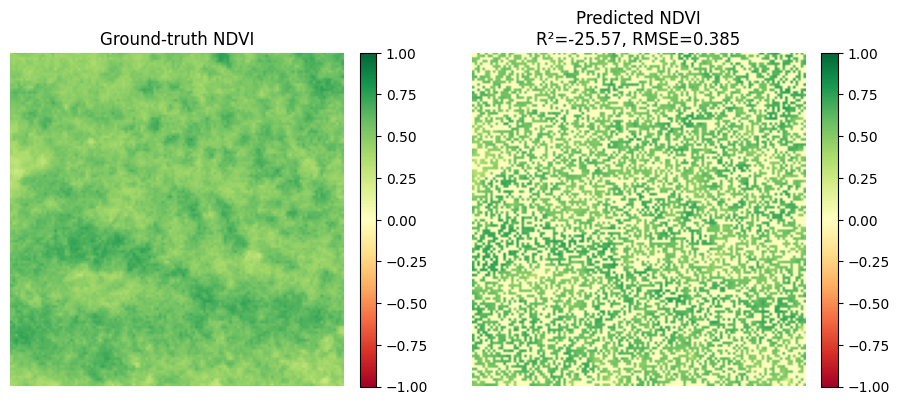

In [36]:
import matplotlib.pyplot as plt
def show_ndvi_comparison(rgb, ndvi_true, ndvi_pred, cmap="RdYlGn"):
    plt.figure(figsize=(14, 4))
    
    # RGB
    # plt.subplot(1, 3, 1)
    # plt.imshow(np.clip(np.moveaxis(rgb.cpu().numpy(), 0, -1), 0, 1))
    # plt.title("RGB Input")
    # plt.axis("off")

    # True NDVI
    plt.subplot(1, 3, 2)
    plt.imshow(ndvi_true, cmap=cmap, vmin=-1, vmax=1)
    plt.title("Ground-truth NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    # Predicted NDVI + Residual
    plt.subplot(1, 3, 3)
    plt.imshow(ndvi_pred, cmap=cmap, vmin=-1, vmax=1)
    plt.title(f"Predicted NDVI\nR²={r2:.2f}, RMSE={rmse:.3f}")
    # plt.title(f"Predicted NDVI")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_ndvi_comparison(rgb_img[0], real_ndvi, pred_ndvi)


In [ ]:
plt.figure(figsize=(6,5))
plt.imshow(real_ndvi - pred_ndvi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.colorbar(label="NDVI Error (True − Pred)")
plt.title("Residual NDVI Heatmap")
plt.axis("off")
plt.show()


In [ ]:
r2_list, rmse_list = [], []
for i in range(len(test_dataset)):
    rgb, ndvi_true = test_dataset[i]
    rgb = rgb.unsqueeze(0).to(DEVICE)
    ndvi_true = ndvi_true.numpy().squeeze()

    with torch.no_grad():
        ndvi_pred = model.predict_ndvi(model(rgb, steps=32)).cpu().numpy().squeeze()

    r2_list.append(r2_score(ndvi_true.flatten(), ndvi_pred.flatten()))
    rmse_list.append(np.sqrt(mean_squared_error(ndvi_true.flatten(), ndvi_pred.flatten())))

print(f"Mean R² = {np.mean(r2_list):.4f}, Mean RMSE = {np.mean(rmse_list):.4f}")


In [ ]:
from IPython.display import clear_output
import time

state = torch.cat([
    rgb_img,
    torch.zeros((1, model.hidden, *rgb_img.shape[2:]), device=DEVICE),
    torch.zeros((1, model.out, *rgb_img.shape[2:]), device=DEVICE),
    torch.ones((1, 1, *rgb_img.shape[2:]), device=DEVICE)
], dim=1)

for step in range(0, 64, 4):
    with torch.no_grad():
        state = model.step(state)
    pred = model.predict_ndvi(state).cpu().numpy().squeeze()
    clear_output(wait=True)
    plt.imshow(pred, cmap="RdYlGn", vmin=-1, vmax=1)
    plt.title(f"Step {step}")
    plt.axis("off")
    plt.show()
    time.sleep(0.2)
